Load the data:

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

final = pd.read_parquet("../data/processed/modeling_table.parquet")
final.head()

,trip_id,stop_id,stop_sequence,delay_seconds,snapshot_time,arrival_time,route_id,route_short_name,scheduled_dt,hour_bucket,temperature_c,hour,weekday,is_rush_hour,is_delayed,delay_minutes,service_date
0,14010000658043366,9022001010759001,67,-417.0,1722476904,27:33:44,9011001059200000,592,2024-08-02 03:33:44,2024-08-02 03:00:00,14.0,3,Friday,0,0.0,-6.950000,2024-08-01
1,14010000658043366,9022001010761003,68,-412.0,1722476921,27:34:04,9011001059200000,592,2024-08-02 03:34:04,2024-08-02 03:00:00,14.0,3,Friday,0,0.0,-6.866667,2024-08-01
2,14010000658043366,9022001010363008,69,-315.0,1722476989,27:35:13,9011001059200000,592,2024-08-02 03:35:13,2024-08-02 03:00:00,14.0,3,Friday,0,0.0,-5.250000,2024-08-01
3,14010000658043366,9022001010019003,70,-412.0,1722476989,27:40:00,9011001059200000,592,2024-08-02 03:40:00,2024-08-02 03:00:00,14.0,3,Friday,0,0.0,-6.866667,2024-08-01
4,14010000658043445,9022001057318001,66,0.0,1722476870,27:36:15,9011001059200000,592,2024-08-02 03:36:15,2024-08-02 03:00:00,14.0,3,Friday,0,0.0,0.000000,2024-08-01


Step 3.1

In [10]:
print(final["delay_minutes"].describe())
print("Share delayed:", final["is_delayed"].mean())

count    2.563673e+06
mean     1.648563e+00
std      3.558121e+00
min     -1.348000e+02
25%     -6.666667e-02
50%      1.083333e+00
75%      2.733333e+00
max      1.660167e+02
Name: delay_minutes, dtype: float64
Share delayed: 0.222668413639337


In [11]:
print(final["delay_seconds"].isna().sum())
print(final["delay_minutes"].isna().sum())

3080
3080


Any trip where the delay was genuinely unknown is currently being silently coded as is_delayed = 0 ("on time") rather than "unknown."

In [12]:
missing = final[final["delay_seconds"].isna()]
print(missing["service_date"].value_counts())
print(missing[["trip_id", "stop_id", "route_short_name"]].head(10))

service_date
2024-02-13    1523
2024-01-16     898
2024-08-01     275
2024-08-02     234
2024-08-03     150
Name: count, dtype: int64
                 trip_id           stop_id route_short_name
28335  14010000660279132  9022001010180001               53
30591  14010000660279178  9022001050012003               57
34661  14010000658115801  9022001005007002               40
39244  14010000658116087  9022001005007002               40
62755  14010000657506000  9022001001281002               19
62756  14010000657506000  9022001001271002               19
62757  14010000657506000  9022001001261002               19
62758  14010000657506000  9022001001251002               19
62759  14010000657506000  9022001001241002               19
62760  14010000657506000  9022001001231002               19


Cheking if the number of NaN inputs are no longer converted to "ontime" and "is_delayed is no longer 0

In [13]:
print(final["is_delayed"].isna().sum())

3080


Droping the rows from the modeling table, since "unknown" isn't a usable label for anything downstream

In [14]:
final_clean = final.dropna(subset=["is_delayed"]).copy()
print(f"Dropped {len(final) - len(final_clean)} rows with unknown delay")
print(f"Remaining: {len(final_clean)} rows")

Dropped 3080 rows with unknown delay
Remaining: 2563673 rows


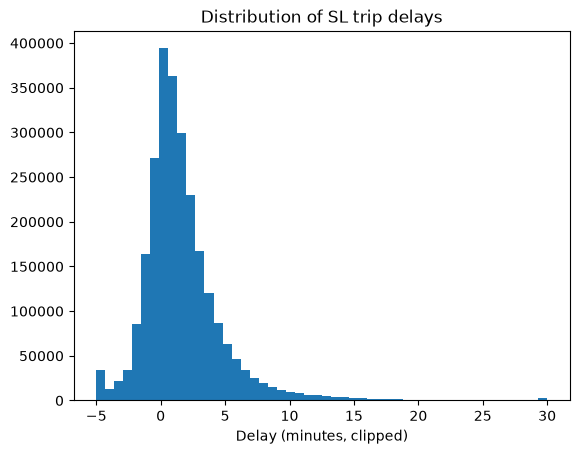

In [15]:
import matplotlib.pyplot as plt

plt.hist(final_clean["delay_minutes"].clip(-5, 30), bins=50)
plt.xlabel("Delay (minutes, clipped)")
plt.title("Distribution of SL trip delays")
plt.show()

Step 3.2: does weather affect delay?

In [17]:
final = pd.read_parquet("../data/processed/modeling_table.parquet")
final_clean = final.dropna(subset=["is_delayed"]).copy()
print(final_clean["temperature_c"].describe())

count    2.563673e+06
mean     8.620101e+00
std      1.320254e+01
min     -1.420000e+01
25%     -4.000000e-01
50%      1.640000e+01
75%      2.050000e+01
max      2.520000e+01
Name: temperature_c, dtype: float64


In [16]:
from scipy import stats

cold = final_clean[final_clean["temperature_c"] < 0]["delay_seconds"]
mild = final_clean[final_clean["temperature_c"] >= 0]["delay_seconds"]

print(f"Cold trips: {len(cold)}, Mild trips: {len(mild)}")
print("Cold median delay:", cold.median())
print("Mild median delay:", mild.median())

Cold trips: 784661, Mild trips: 1779012
Cold median delay: 107.0
Mild median delay: 50.0


In [18]:
stat, p = stats.mannwhitneyu(cold, mild, alternative="two-sided")
print(f"U={stat:.1f}, p={p:.4f}")

U=873568421040.5, p=0.0000


p=0.0000 confirms the difference is statistically significant, but as flagged, with 2.5 million+ rows, almost any real difference would clear that bar, so the p-value alone isn't the interesting part here. The interesting part is the effect size you already have: median delay more than doubling in cold weather (107s vs 50s) is a substantively large, practically meaningful difference

In [19]:
print(final_clean.groupby("service_date")["temperature_c"].agg(["min", "max", "mean"]))

               min   max       mean
service_date                       
2024-01-16   -14.2  -3.0 -12.648587
2024-02-13    -4.8   0.4  -0.425250
2024-08-01    14.0  23.3  19.483138
2024-08-02    14.0  22.7  19.282829
2024-08-03    16.1  25.2  19.765237


Weather and delay: cold trips (<0°C, n=784,661) show a median delay of 107 seconds vs. 50 seconds for mild trips (≥0°C, n=1,779,012) (more than double), Mann-Whitney p<0.0001. However, temperature and date are completely non-overlapping in this sample (each date falls entirely into one temperature band, see groupby check), meaning this test cannot separate a genuine weather effect from any other systematic difference between winter and summer service days (traffic, daylight, maintenance schedules, etc.). A dataset with temperature variation within a single season, or many dates spanning both regimes, would be needed to isolate weather specifically as the cause.

Step 3.3: does time of day (rush hour vs. off-peak) affect delay?

This time instead of Mann-Whitney which only compares two groups, I am going to use Kruskal-Wallis which gives us the option to see if any group is actually different than others. In below I am going to distinct 4 different groups and test the hypothesis.

In [20]:
buckets = {
    "early": final_clean["hour"].between(4, 6),
    "morning_rush": final_clean["hour"].between(7, 9),
    "midday": final_clean["hour"].between(10, 15),
    "evening_rush": final_clean["hour"].between(16, 18),
    "night": ~final_clean["hour"].between(4, 18),
}

for name, mask in buckets.items():
    print(name, mask.sum(), "trips, median delay:", final_clean.loc[mask, "delay_seconds"].median())

groups = [final_clean.loc[mask, "delay_seconds"] for mask in buckets.values()]

stat, p = stats.kruskal(*groups)
print(f"\nH={stat:.1f}, p={p:.4f}")

early 236007 trips, median delay: 64.0
morning_rush 492441 trips, median delay: 67.0
midday 871773 trips, median delay: 67.0
evening_rush 461974 trips, median delay: 72.0
night 501478 trips, median delay: 59.0

H=4835.2, p=0.0000


One thing genuinely worth checking before writing this up: is rush hour actually worse, or does it just look mildly worse in the median while telling a different story elsewhere in the distribution? Medians alone can hide things e.g., rush hour could have a similar median but a much heavier tail of really bad delays, which matters practically (a few very late trips can wreck someone's commute) even if the typical trip looks similar.

In [21]:
for name, mask in buckets.items():
    subset = final_clean.loc[mask, "delay_seconds"]
    print(f"{name}: median={subset.median():.0f}s, 90th pct={subset.quantile(0.9):.0f}s, share >180s={ (subset > 180).mean():.3f}")

early: median=64s, 90th pct=258s, share >180s=0.188
morning_rush: median=67s, 90th pct=367s, share >180s=0.251
midday: median=67s, 90th pct=287s, share >180s=0.218
evening_rush: median=72s, 90th pct=353s, share >180s=0.261
night: median=59s, 90th pct=252s, share >180s=0.184


Time of day and delay: Kruskal-Wallis confirms a statistically significant difference across time buckets (H=4835.2, p<0.0001), but medians alone understate the effect, they range narrowly from 59s (night) to 72s (evening rush). The real pattern shows up in the tail: 25.1% of morning-rush trips and 26.1% of evening-rush trips exceed the 180s delay threshold, versus 18.4-18.8% for early/night, roughly a 7-8 percentage point gap. Rush hour doesn't much change the typical trip's delay, but it noticeably increases how often a trip is seriously delayed. This is a stronger, more actionable finding than the median comparison alone would suggest.